Loaded 301 rows, 9 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
               count unique     top freq         mean           std     min  \
Car_Name         301     98    city   26          NaN           NaN     NaN   
Year           301.0    NaN     NaN  NaN  2013.627907      2.891554  2003.0   
Selling_Price  301.0    NaN     NaN  NaN     4.661296      5.082812     0.1   
P

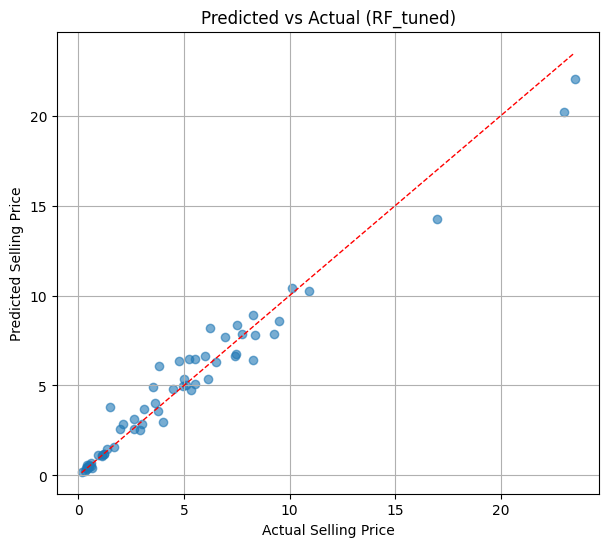

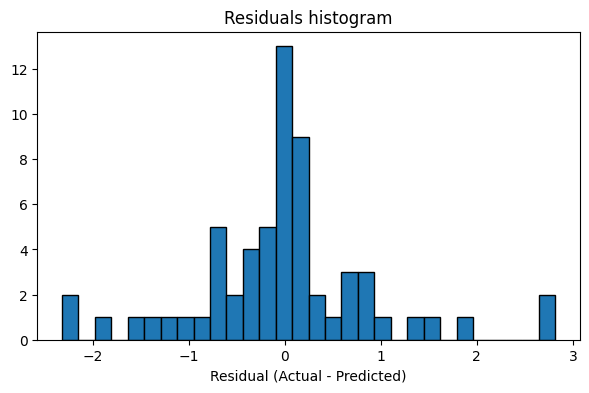

                     feature  importance
0              Present_Price    0.457904
4          Log_Present_Price    0.421575
3                    Car_Age    0.050122
1                 Driven_kms    0.018822
5             Log_Driven_kms    0.017362
100      Transmission_Manual    0.004744
99    Transmission_Automatic    0.003912
68             Car_Name_city    0.003691
79         Car_Name_fortuner    0.003562
86     Car_Name_land cruiser    0.003294
96          Fuel_Type_Petrol    0.003031
69    Car_Name_corolla altis    0.002544
98   Selling_type_Individual    0.002411
84           Car_Name_innova    0.001887
97       Selling_type_Dealer    0.001222
95          Fuel_Type_Diesel    0.001163
91            Car_Name_verna    0.000618
70            Car_Name_creta    0.000441
67             Car_Name_ciaz    0.000313
85             Car_Name_jazz    0.000271


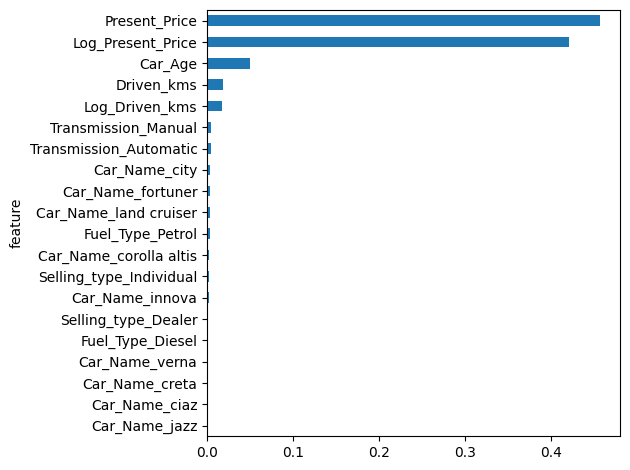

Saved sample predictions to predictions_sample.csv


In [22]:
import math
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#load data
DATA_PATH = Path("car.csv")   # Change to your file path if needed
OUTPUT_MODEL_PATH = Path("best_car_pipeline.pkl")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found. Place your car.csv here or change DATA_PATH.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")

#print(EDA)
print(df.info())
print(df.describe(include='all').T.head(20))
print("Categorical value counts (sample):")
for c in df.select_dtypes(include=['object', 'category']).columns:
    print(c, df[c].value_counts().to_dict())

#target column
TARGET = "Selling_Price"
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset columns: {list(df.columns)}")

# (modify based on dataset):
CURRENT_YEAR = 2025  # set to current year for Car_Age
if 'Year' in df.columns:
    df['Car_Age'] = CURRENT_YEAR - df['Year']
# log1p transform of Present_Price or Driven_kms 
df['Log_Present_Price'] = np.log1p(df['Present_Price']) if 'Present_Price' in df.columns else np.nan
df['Log_Driven_kms'] = np.log1p(df['Driven_kms']) if 'Driven_kms' in df.columns else np.nan

# Remove  redundant columns 
drop_cols = []
if 'Year' in df.columns:
    drop_cols.append('Year')  
# drop if present
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

#prepare x and y
y = df[TARGET].copy()
X = df.drop(columns=[TARGET])

# Split types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)


#  Preprocessing pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))

])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder='drop' 
)

# Models & pipelines
lr_pipe = Pipeline([
    ("pre", preprocessor),
    ("reg", LinearRegression())
])

rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("reg", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# regularized linear model
ridge_pipe = Pipeline([
    ("pre", preprocessor),
    ("reg", Ridge())
])

#train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train baselinr model
print("Training Linear Regression...")
lr_pipe.fit(X_train, y_train)

print("Training Random Forest (default hyperparams)...")
rf_pipe.fit(X_train, y_train)

print("Training Ridge...")
ridge_pipe.fit(X_train, y_train)


# Evaluation 
def eval_model(pipe, X_test, y_test):
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = math.sqrt(mse)          # version-safe
    r2 = r2_score(y_test, preds)
    return {"preds": preds, "MAE": mae, "RMSE": rmse, "R2": r2}

lr_eval = eval_model(lr_pipe, X_test, y_test)
rf_eval = eval_model(rf_pipe, X_test, y_test)
ridge_eval = eval_model(ridge_pipe, X_test, y_test)

results = pd.DataFrame([
    {"Model": "LinearRegression", **{k: lr_eval[k] for k in ['MAE','RMSE','R2']}},
    {"Model": "RandomForest", **{k: rf_eval[k] for k in ['MAE','RMSE','R2']}},
    {"Model": "Ridge", **{k: ridge_eval[k] for k in ['MAE','RMSE','R2']}}
])
print(results.sort_values("RMSE"))

#cross validation
print("Cross-validating RandomForest (5-fold, neg_root_mean_squared_error)...")
cv_scores = cross_val_score(rf_pipe, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
print("RF CV RMSE (5-fold):", -cv_scores.mean(), "(std:", cv_scores.std(), ")")

#hyperparameter tuning
param_grid = {
    "reg__n_estimators": [100, 200],
    "reg__max_depth": [None, 12, 20],
    "reg__min_samples_leaf": [1, 3, 5]
}
gs = GridSearchCV(rf_pipe, param_grid, cv=4, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
print("Running GridSearchCV for RandomForest (this may take time)...")
gs.fit(X_train, y_train)
print("Best RF params:", gs.best_params_)
best_rf = gs.best_estimator_
best_rf_eval = eval_model(best_rf, X_test, y_test)
print("Best RF evaluation:", best_rf_eval)
#choose best model and save
candidates = {
    "Linear": lr_eval["RMSE"],
    "Ridge": ridge_eval["RMSE"],
    "RF_default": rf_eval["RMSE"],
    "RF_tuned": best_rf_eval["RMSE"]
}
best_name = min(candidates, key=candidates.get)
print("Best by RMSE:", best_name)

best_pipeline = {"Linear": lr_pipe, "Ridge": ridge_pipe, "RF_default": rf_pipe, "RF_tuned": best_rf}[best_name]
joblib.dump(best_pipeline, OUTPUT_MODEL_PATH)
print("Saved best pipeline to", OUTPUT_MODEL_PATH)

#visualisation
preds = best_pipeline.predict(X_test)
plt.figure(figsize=(7,6))
plt.scatter(y_test, preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Predicted vs Actual ({best_name})")
plt.grid(True)
plt.show()

resid = y_test - preds
plt.figure(figsize=(7,4))
plt.hist(resid, bins=30, edgecolor='black')
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residuals histogram")
plt.show()

# If model is tree-based, show feature importances
if best_name.startswith("RF"):
    preprocessor.fit(X_train)
    feature_names = numeric_cols.copy()
    if cat_cols:
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        feature_names.extend(list(ohe.get_feature_names_out(cat_cols)))
    importances = best_pipeline.named_steps['reg'].feature_importances_
    fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
    print(fi.head(20))
    fi.head(20).plot.barh(x='feature', y='importance', legend=False)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

#save prediction sample
out_df = X_test.copy().reset_index(drop=True)
out_df['Actual_Selling_Price'] = y_test.reset_index(drop=True)
out_df['Predicted_Selling_Price'] = preds
out_df.head(10).to_csv("predictions_sample.csv", index=False)
print("Saved sample predictions to predictions_sample.csv")
